In [1]:
import os
region="delhi_airshed"
# # Paths
# image_dir = f"../../data/processed_data/{region}/images"
# label_dir_yolo = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/{region}/labels"
# label_dir_voc = f"../data/staclip/{region}/labels_voc"

# # Create output directory if not exists
# os.makedirs(label_dir_voc, exist_ok=True)

# # Process each label file
# for fname in os.listdir(label_dir_yolo):
#     if not fname.endswith('.txt'):
#         continue

#     label_path = os.path.join(label_dir_yolo, fname)
#     image_path = os.path.join(image_dir, fname.replace(".txt", ".tif"))

#     if not os.path.exists(image_path):
#         continue

#     # Get image dimensions
#     from PIL import Image
#     img = Image.open(image_path)
#     w, h = img.size

#     pascal_boxes = []

#     with open(label_path, 'r') as f:
#         for line in f:
#             parts = list(map(float, line.strip().split()))
#             if len(parts) != 9:
#                 continue
#             cls = int(parts[0])
#             coords = parts[1:]
#             x_coords = coords[::2]
#             y_coords = coords[1::2]
#             x_min, x_max = min(x_coords), max(x_coords)
#             y_min, y_max = min(y_coords), max(y_coords)
#             # Clip to image size
#             x_min = max(0, min(x_min * w, w))
#             x_max = max(0, min(x_max * w, w))
#             y_min = max(0, min(y_min * h, h))
#             y_max = max(0, min(y_max * h, h))
#             pascal_boxes.append([cls, x_min, y_min, x_max, y_max])

#     # Save in Pascal VOC format: cls x_min y_min x_max y_max
#     output_path = os.path.join(label_dir_voc, fname)
#     with open(output_path, 'w') as f_out:
#         for box in pascal_boxes:
#             f_out.write(f"{int(box[0])} {box[1]:.2f} {box[2]:.2f} {box[3]:.2f} {box[4]:.2f}\n")

# label_dir_voc

Processing 9021406_3115876 with 12 objects...


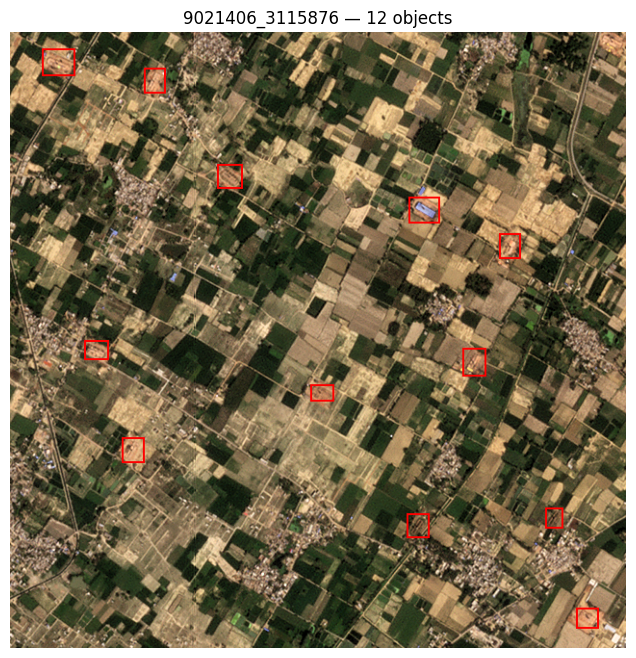

Processing 8988385_3137890 with 12 objects...


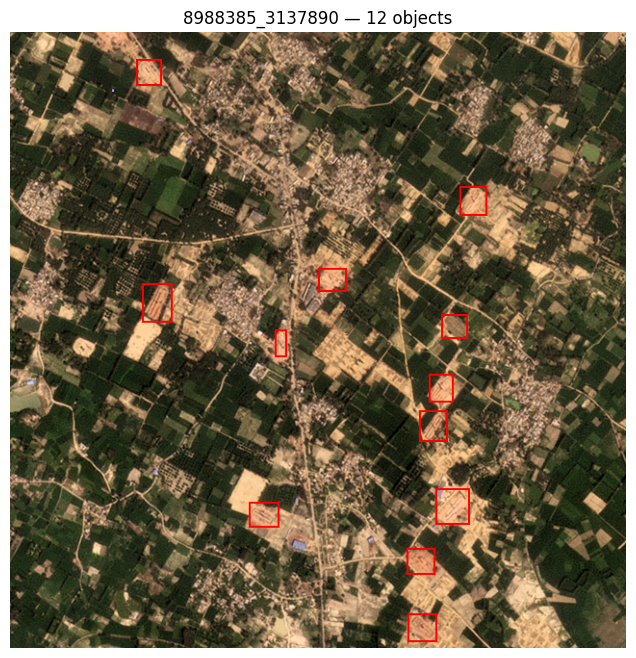

Processing 9040668_3088359 with 12 objects...


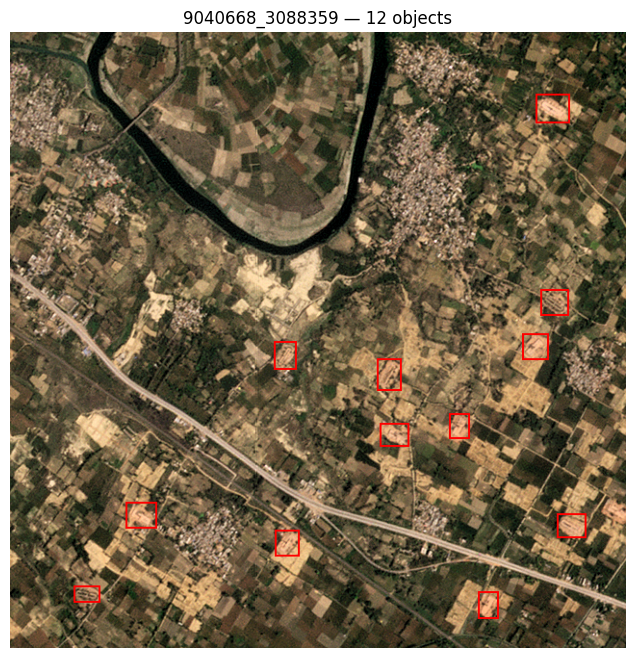

Processing 9032413_3107621 with 11 objects...


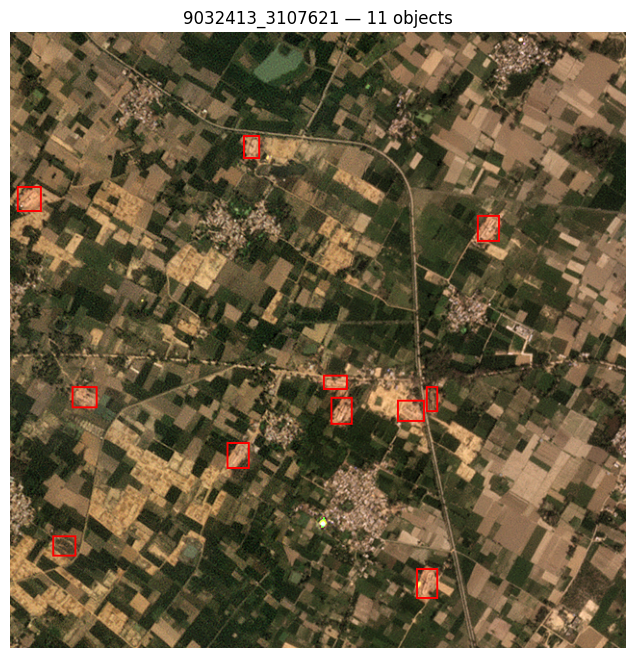

Processing 9004895_3118628 with 11 objects...


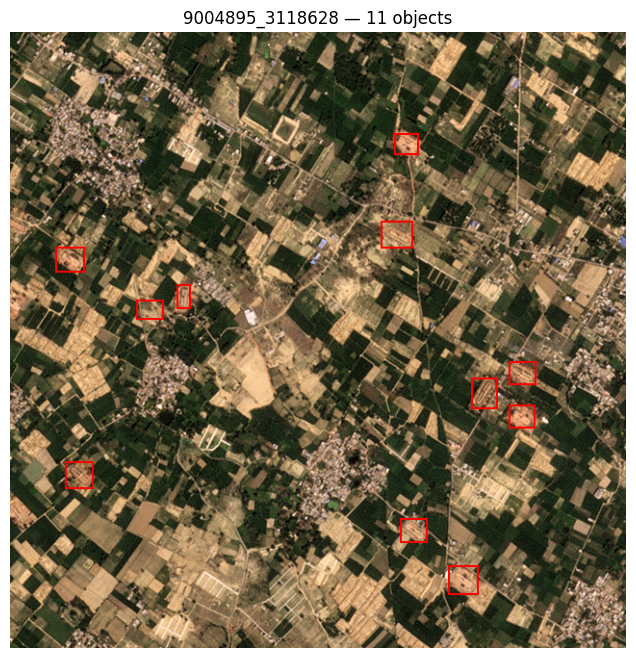

In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Paths
image_dir = f"../../data/processed_data/{region}/images"
label_dir_voc = f"../data/staclip/{region}/labels_voc"

# Step 1: Count objects in each annotation
image_object_counts = {}

for fname in os.listdir(label_dir_voc):
    if not fname.endswith('.txt'):
        continue
    txt_path = os.path.join(label_dir_voc, fname)
    with open(txt_path, 'r') as f:
        count = sum(1 for line in f if line.strip())
    image_id = os.path.splitext(fname)[0]
    image_object_counts[image_id] = count

# Step 2: Select top 5 by density
top5 = sorted(image_object_counts.items(), key=lambda x: x[1], reverse=True)[:5]

# Step 3: Plot the top 5 with bounding boxes
for image_id, count in top5:
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    print(f"Processing {image_id} with {count} objects...")
    label_path = os.path.join(label_dir_voc, f"{image_id}.txt")

    # Load image
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # Parse and draw bounding boxes from plain text file
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_min, y_min, x_max, y_max = parts
            x_min = int(float(x_min))
            y_min = int(float(y_min))
            x_max = int(float(x_max))
            y_max = int(float(y_max))
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)

    # Show image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"{image_id} — {count} objects")
    plt.axis("off")
    plt.show()


In [ ]:
import os
from PIL import Image

# Paths
image_dir = f"../../data/processed_data/{region}/images"
label_dir_voc = f"../data/staclip/{region}/labels_voc"
crop_save_dir = f"../data/brick_kiln_crops/{region}_64x64"
os.makedirs(crop_save_dir, exist_ok=True)

crop_id = 0

# Process all label files
for fname in os.listdir(label_dir_voc):
    if not fname.endswith('.txt'):
        continue

    image_id = os.path.splitext(fname)[0]
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    label_path = os.path.join(label_dir_voc, fname)

    if not os.path.exists(image_path):
        print(f"Warning: image not found for {image_id}")
        continue

    image = Image.open(image_path).convert("RGB")

    with open(label_path, 'r') as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            _, x_min, y_min, x_max, y_max = parts
            x_min = int(float(x_min))
            y_min = int(float(y_min))
            x_max = int(float(x_max))
            y_max = int(float(y_max))

            # Crop and resize
            crop = image.crop((x_min, y_min, x_max, y_max)).resize((64, 64), Image.BICUBIC)

            # Save with unique filename
            crop_filename = f"{image_id}_obj{i}_crop{crop_id}.png"
            crop.save(os.path.join(crop_save_dir, crop_filename))
            crop_id += 1

print(f"✅ Saved {crop_id} total cropped 64x64 patches to: {crop_save_dir}")


✅ Saved 496 total cropped 64x64 patches to: ../data/brick_kiln_crops/lucknow_airshed_64x64


In [2]:
import os
import random
from PIL import Image
from scipy.spatial import KDTree

region = "delhi_airshed"
image_dir = f"../../data/processed_data/{region}/images"
label_dir_voc = f"../data/staclip/{region}/labels_voc"
crop_save_dir = f"../data/brick_kiln_crops/delhi_airshed_negetive_64x64"
os.makedirs(crop_save_dir, exist_ok=True)

patch_size = 64
safe_distance = 100  # in pixels
num_attempts = 100  # max attempts per image

crop_id = 0

for fname in os.listdir(image_dir):
    if not fname.endswith(".tif"):
        continue

    image_id = os.path.splitext(fname)[0]
    image_path = os.path.join(image_dir, fname)
    label_path = os.path.join(label_dir_voc, f"{image_id}.txt")
    image = Image.open(image_path).convert("RGB")
    w, h = image.size

    # Parse bounding box centers
    centers = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, x_min, y_min, x_max, y_max = map(float, parts)
                cx = (x_min + x_max) / 2
                cy = (y_min + y_max) / 2
                centers.append((cx, cy))

    tree = KDTree(centers) if centers else None

    attempts = 0
    found = 0
    while attempts < num_attempts and found < 3:  # limit 3 patches/image
        cx = random.randint(patch_size // 2, w - patch_size // 2)
        cy = random.randint(patch_size // 2, h - patch_size // 2)

        if tree:
            d, _ = tree.query([cx, cy])
            if d < safe_distance:
                attempts += 1
                continue  # too close, skip

        # Valid negative patch
        x_min = cx - patch_size // 2
        y_min = cy - patch_size // 2
        x_max = x_min + patch_size
        y_max = y_min + patch_size

        crop = image.crop((x_min, y_min, x_max, y_max))
        crop_filename = f"{image_id}_neg{crop_id}.png"
        crop.save(os.path.join(crop_save_dir, crop_filename))
        crop_id += 1
        found += 1

print(f"✅ Saved {crop_id} negative 64x64 patches to: {crop_save_dir}")


✅ Saved 3348 negative 64x64 patches to: ../data/brick_kiln_crops/delhi_airshed_negetive_64x64


In [3]:
import os
from PIL import Image

region = "delhi_airshed"
image_dir = f"../../data/processed_data/{region}/images"
label_dir = f"../data/staclip/{region}/labels_voc"
save_dir = f"../data/brick_kiln_crops/micro_patches/{region}_64x64_pos"
os.makedirs(save_dir, exist_ok=True)

crop_id = 0

for fname in os.listdir(label_dir):
    if not fname.endswith(".txt"):
        continue

    image_id = os.path.splitext(fname)[0]
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    label_path = os.path.join(label_dir, fname)

    if not os.path.exists(image_path):
        print(f"Image not found: {image_id}")
        continue

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    with open(label_path, "r") as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            _, x_min, y_min, x_max, y_max = map(float, parts)
            cx = int((x_min + x_max) / 2)
            cy = int((y_min + y_max) / 2)

            x0 = max(cx - 32, 0)
            y0 = max(cy - 32, 0)
            x1 = min(x0 + 64, width)
            y1 = min(y0 + 64, height)

            if x1 - x0 < 64 or y1 - y0 < 64:
                continue  # skip if too close to border

            crop = image.crop((x0, y0, x1, y1))
            crop_fname = f"{image_id}_pos{i}_crop{crop_id}.png"
            crop.save(os.path.join(save_dir, crop_fname))
            crop_id += 1

print(f"✅ Saved {crop_id} centered 64×64 positive patches to: {save_dir}")


✅ Saved 773 centered 64×64 positive patches to: ../data/brick_kiln_crops/micro_patches/delhi_airshed_64x64_pos


In [4]:
import os
import csv
from PIL import Image

region = "lucknow_airshed"
image_dir = f"../../data/processed_data/{region}/images"
save_dir = f"../data/brick_kiln_crops/micro_patches/{region}_64x64_unlabeled"
os.makedirs(save_dir, exist_ok=True)

metadata_path = os.path.join(save_dir, "patch_metadata.csv")
patch_size = 64
stride = 64
crop_id = 0

with open(metadata_path, mode='w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["patch_name", "image_name", "x", "y"])  # header

    for fname in os.listdir(image_dir):
        if not fname.endswith(".tif"):
            continue

        image_path = os.path.join(image_dir, fname)
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):
                patch = image.crop((x, y, x + patch_size, y + patch_size))
                patch_name = f"{os.path.splitext(fname)[0]}_x{x}_y{y}_crop{crop_id}.png"
                patch.save(os.path.join(save_dir, patch_name))
                writer.writerow([patch_name, fname, x, y])
                crop_id += 1

print(f"✅ Saved {crop_id} patches and metadata to: {save_dir}")


✅ Saved 59800 patches and metadata to: ../data/brick_kiln_crops/micro_patches/lucknow_airshed_64x64_unlabeled
